In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


In [7]:
!ls -lah


total 6.8M
drwxr-xr-x 1 root root 4.0K Feb 27 22:23 .
drwxr-xr-x 1 root root 4.0K Feb 27 22:16 ..
-rw-r--r-- 1 root root 6.8M Feb 27 22:23 AB_NYC_2019.csv
drwxr-xr-x 4 root root 4.0K Jan 16 14:24 .config
drwxr-xr-x 1 root root 4.0K Jan 16 14:24 sample_data


In [8]:
import pandas as pd

df = pd.read_csv("/content/AB_NYC_2019.csv")
df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [9]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))


Shape: (48895, 16)

Columns:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Data types:
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

Missing values:


In [10]:
df = df.drop(columns=["id", "name", "host_id", "host_name", "last_review"])
df.head()


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [11]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

print(df.isna().sum().sort_values(ascending=False))


neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


In [12]:
X = df.drop("price", axis=1)
y = df["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (48895, 10)
Target shape: (48895,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (39116, 10)
Test shape: (9779, 10)


In [14]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)


Categorical: ['neighbourhood_group', 'neighbourhood', 'room_type']
Numerical: ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [15]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessing for numerical data
numeric_transformer = StandardScaler()

# Preprocessing for categorical data
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


In [16]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train
linear_model.fit(X_train, y_train)

# Predict
y_pred_linear = linear_model.predict(X_test)


In [17]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred_linear)
mae = mean_absolute_error(y_test, y_pred_linear)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))

print("Linear Regression Performance:")
print("R²:", round(r2, 4))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))


Linear Regression Performance:
R²: 0.1359
MAE: 68.15
RMSE: 195.52


In [18]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("Ridge Regression Performance:")
print("R²:", round(r2_ridge, 4))
print("MAE:", round(mae_ridge, 2))
print("RMSE:", round(rmse_ridge, 2))


Ridge Regression Performance:
R²: 0.137
MAE: 68.07
RMSE: 195.39


In [19]:
# Get feature names after preprocessing
feature_names = (
    numerical_cols +
    list(ridge_model.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .get_feature_names_out(categorical_cols))
)

coefficients = ridge_model.named_steps["model"].coef_

import pandas as pd

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(by="Coefficient", key=abs, ascending=False)

coef_df.head(15)


,Feature,Coefficient
186,neighbourhood_Sea Gate,447.712904
173,neighbourhood_Randall Manor,300.649646
94,neighbourhood_Fort Wadsworth,298.599622
179,neighbourhood_Riverdale,290.755001
209,neighbourhood_Tribeca,243.629914
169,neighbourhood_Prince's Bay,168.354075
18,neighbourhood_Battery Park City,145.735515
11,neighbourhood_group_Staten Island,-140.203413
48,neighbourhood_City Island,137.927490
87,neighbourhood_Flatiron District,118.202082


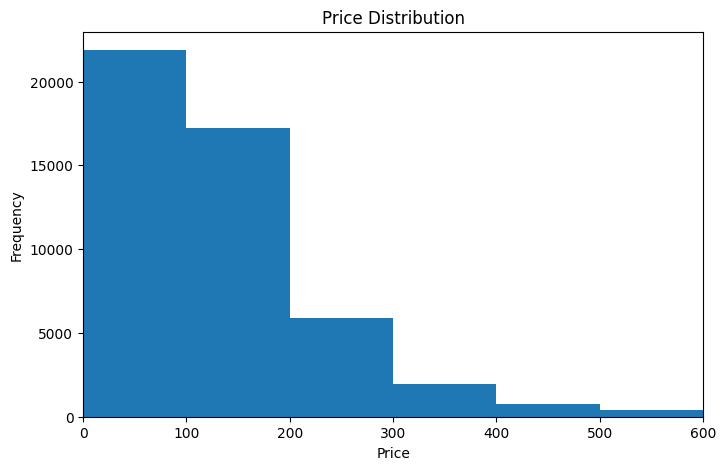

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=100)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.xlim(0, 600)
plt.show()


In [21]:
import numpy as np

y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log,
    test_size=0.2,
    random_state=RANDOM_STATE
)

linear_model_log = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model_log.fit(X_train, y_train_log)

y_pred_log = linear_model_log.predict(X_test)

r2_log = r2_score(y_test_log, y_pred_log)
mae_log = mean_absolute_error(y_test_log, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test_log, y_pred_log))

print("Log-Linear Regression Performance:")
print("R²:", round(r2_log, 4))
print("MAE:", round(mae_log, 4))
print("RMSE:", round(rmse_log, 4))


Log-Linear Regression Performance:
R²: 0.5499
MAE: 0.3347
RMSE: 0.4615


In [22]:
from sklearn.linear_model import Ridge

ridge_model_log = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model_log.fit(X_train, y_train_log)

y_pred_ridge_log = ridge_model_log.predict(X_test)

r2_ridge_log = r2_score(y_test_log, y_pred_ridge_log)
mae_ridge_log = mean_absolute_error(y_test_log, y_pred_ridge_log)
rmse_ridge_log = np.sqrt(mean_squared_error(y_test_log, y_pred_ridge_log))

print("Log-Ridge Regression Performance:")
print("R²:", round(r2_ridge_log, 4))
print("MAE:", round(mae_ridge_log, 4))
print("RMSE:", round(rmse_ridge_log, 4))


Log-Ridge Regression Performance:
R²: 0.5503
MAE: 0.3346
RMSE: 0.4613


In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=80,       # slightly fewer trees
        max_depth=15,          # limit depth
        min_samples_split=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train_log)

y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test_log, y_pred_rf)
mae_rf = mean_absolute_error(y_test_log, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_log, y_pred_rf))

print("Random Forest (Log Target) Performance:")
print("R²:", round(r2_rf, 4))
print("MAE:", round(mae_rf, 4))
print("RMSE:", round(rmse_rf, 4))


Random Forest (Log Target) Performance:
R²: 0.6153
MAE: 0.3036
RMSE: 0.4266


In [24]:
import pandas as pd

rf = rf_model.named_steps["model"]

feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(15)


,Feature,Importance
232,cat__room_type_Entire home/apt,0.482046
1,num__longitude,0.117665
0,num__latitude,0.109782
6,num__availability_365,0.063645
2,num__minimum_nights,0.042117
9,cat__neighbourhood_group_Manhattan,0.040624
4,num__reviews_per_month,0.032090
5,num__calculated_host_listings_count,0.028549
3,num__number_of_reviews,0.025384
139,cat__neighbourhood_Midtown,0.006986


In [25]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": [
        "Linear (Raw)",
        "Linear (Log)",
        "Ridge (Log)",
        "Random Forest (Log)"
    ],
    "R2": [
        0.1359,
        r2_log,
        r2_ridge_log,
        r2_rf
    ],
    "MAE": [
        68.15,
        mae_log,
        mae_ridge_log,
        mae_rf
    ],
    "RMSE": [
        195.52,
        rmse_log,
        rmse_ridge_log,
        rmse_rf
    ]
})

results_df


,Model,R2,MAE,RMSE
0,Linear (Raw),0.135900,68.150000,195.520000
1,Linear (Log),0.549855,0.334720,0.461474
2,Ridge (Log),0.550285,0.334622,0.461253
3,Random Forest (Log),0.615308,0.303574,0.426606


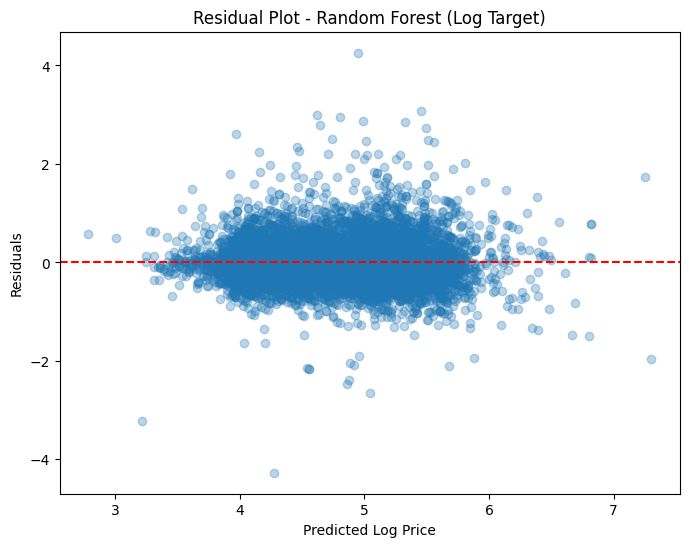

In [26]:
import matplotlib.pyplot as plt
import numpy as np

residuals = y_test_log - y_pred_rf

plt.figure(figsize=(8,6))
plt.scatter(y_pred_rf, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Log Price")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest (Log Target)")
plt.show()


In [27]:
from sklearn.preprocessing import StandardScaler

# Select features for clustering
cluster_features = df[[
    "price",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "minimum_nights",
    "calculated_host_listings_count",
    "latitude",
    "longitude"
]].copy()

# Log-transform price (consistent with regression insight)
cluster_features["price"] = np.log1p(cluster_features["price"])

# Scale features
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)


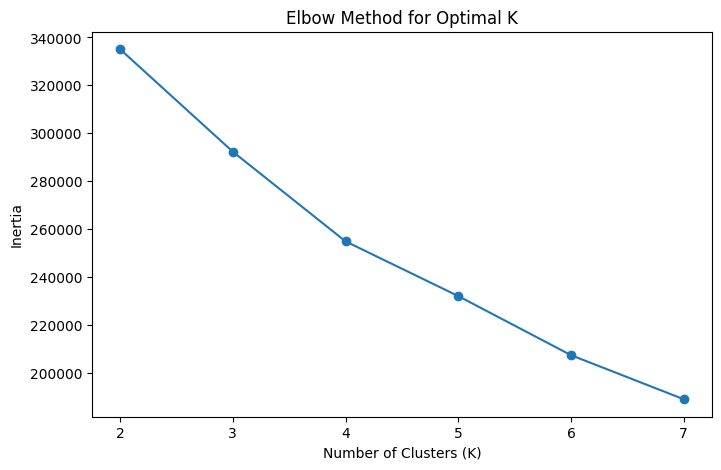

In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()


In [29]:
kmeans_final = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
df["Cluster"] = kmeans_final.fit_predict(cluster_scaled)

df["Cluster"].value_counts()


,count
Cluster,
0,28475
2,12277
1,7584
3,559


In [30]:
cluster_summary = df.groupby("Cluster")[[
    "price",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "minimum_nights",
    "calculated_host_listings_count"
]].mean()

cluster_summary


,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights,calculated_host_listings_count
Cluster,,,,,,
0,138.523512,22.821001,8.430026,0.505110,4.759192,1.686111
1,120.749736,153.863660,96.267537,3.875944,2.500923,2.119330
2,199.880182,288.363688,13.566588,0.745969,14.451576,10.138226
3,273.928444,281.703041,2.343470,0.722004,21.150268,287.572451


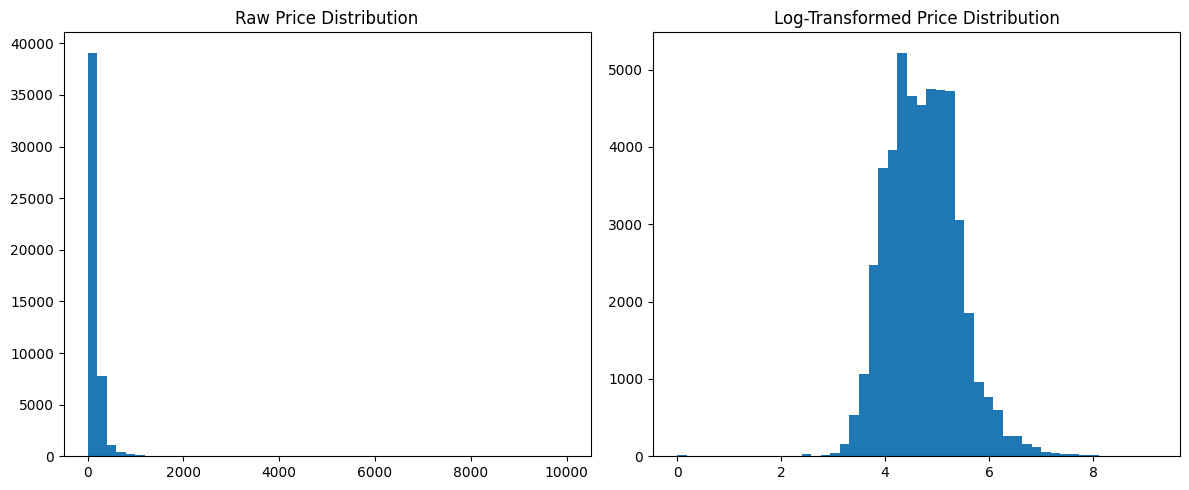

In [31]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df["price"], bins=50)
plt.title("Raw Price Distribution")

plt.subplot(1,2,2)
plt.hist(np.log1p(df["price"]), bins=50)
plt.title("Log-Transformed Price Distribution")

plt.tight_layout()
plt.show()


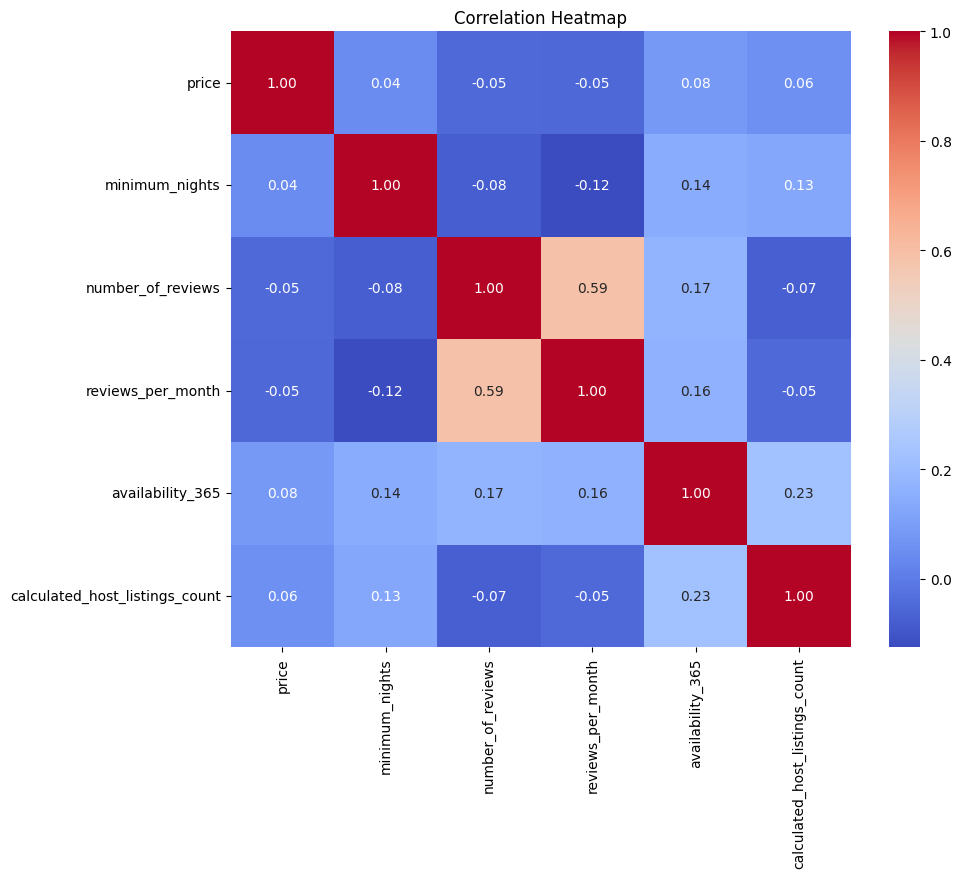

In [32]:
import seaborn as sns

plt.figure(figsize=(10,8))
corr = df[[
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365",
    "calculated_host_listings_count"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
